# Use Real Images for Processing or Somethin

This notebook runs MPI-based image processing using C++ (CUDA + MPI + OpenMP).

We dynamically pass images into the parallel program and test performance across multiple processor counts.

but yea that how it works idk

In [1]:
import subprocess
import re
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os
print(os.getcwd())

c:\Users\nyoma\Downloads\mpyCUDA\Kamen-Rider-Image-Convolution


In [3]:
from pathlib import Path
import os

cwd = Path(os.getcwd())
blur_dir = (cwd / "images" / "output" / "blur").resolve()
edge_dir = (cwd / "images" / "output" / "edge").resolve()
sobel_dir = (cwd / "images" / "output" / "sobel").resolve()
sharpen_dir = (cwd / "images" / "output" / "sharpen").resolve()
emboss_dir = (cwd / "images" / "output" / "emboss").resolve()


print("CWD:", cwd.resolve())
print("Blur dir:", blur_dir, "exists:", blur_dir.exists())
print("Edge dir:", edge_dir, "exists:", edge_dir.exists())
print("Sobel dir:", sobel_dir, "exists:", sobel_dir.exists())
print("Sharpen dir:", sharpen_dir, "exists:", sharpen_dir.exists())
print("Emboss dir:", emboss_dir, "exists:", emboss_dir.exists())

print("\nBlur files:")
print(sorted([p.name for p in blur_dir.glob("*")]) if blur_dir.exists() else "MISSING DIR")

print("\nEdge files:")
print(sorted([p.name for p in edge_dir.glob("*")]) if edge_dir.exists() else "MISSING DIR")

print("\nSobel files:")
print(sorted([p.name for p in sobel_dir.glob("*")]) if sobel_dir.exists() else "MISSING DIR")

print("\nSharoen files:")
print(sorted([p.name for p in sharpen_dir.glob("*")]) if sharpen_dir.exists() else "MISSING DIR")

print("\nEmboss files:")
print(sorted([p.name for p in emboss_dir.glob("*")]) if emboss_dir.exists() else "MISSING DIR")

CWD: C:\Users\nyoma\Downloads\mpyCUDA\Kamen-Rider-Image-Convolution
Blur dir: C:\Users\nyoma\Downloads\mpyCUDA\Kamen-Rider-Image-Convolution\images\output\blur exists: True
Edge dir: C:\Users\nyoma\Downloads\mpyCUDA\Kamen-Rider-Image-Convolution\images\output\edge exists: True
Sobel dir: C:\Users\nyoma\Downloads\mpyCUDA\Kamen-Rider-Image-Convolution\images\output\sobel exists: True
Sharpen dir: C:\Users\nyoma\Downloads\mpyCUDA\Kamen-Rider-Image-Convolution\images\output\sharpen exists: True
Emboss dir: C:\Users\nyoma\Downloads\mpyCUDA\Kamen-Rider-Image-Convolution\images\output\emboss exists: True

Blur files:
['decade', 'kuuga', 'ryuki', 'w_lunatrigger']

Edge files:
['decade', 'kuuga', 'ryuki', 'w_lunatrigger']

Sobel files:
['decade', 'kuuga', 'ryuki', 'w_lunatrigger']

Sharoen files:
['decade', 'kuuga', 'ryuki', 'w_lunatrigger']

Emboss files:
['decade', 'kuuga', 'ryuki', 'w_lunatrigger']


Running: C:\Users\nyoma\scoop\apps\msmpi\10.1.1\mpiexec.exe -n 2 ./scripts/parallel_image.exe images\decade.jpg images\output\blur\decade\decade_2.jpg blur
Running: C:\Users\nyoma\scoop\apps\msmpi\10.1.1\mpiexec.exe -n 4 ./scripts/parallel_image.exe images\decade.jpg images\output\blur\decade\decade_4.jpg blur
Running: C:\Users\nyoma\scoop\apps\msmpi\10.1.1\mpiexec.exe -n 6 ./scripts/parallel_image.exe images\decade.jpg images\output\blur\decade\decade_6.jpg blur
Running: C:\Users\nyoma\scoop\apps\msmpi\10.1.1\mpiexec.exe -n 8 ./scripts/parallel_image.exe images\decade.jpg images\output\blur\decade\decade_8.jpg blur
Running: C:\Users\nyoma\scoop\apps\msmpi\10.1.1\mpiexec.exe -n 16 ./scripts/parallel_image.exe images\decade.jpg images\output\blur\decade\decade_16.jpg blur
Running: C:\Users\nyoma\scoop\apps\msmpi\10.1.1\mpiexec.exe -n 24 ./scripts/parallel_image.exe images\decade.jpg images\output\blur\decade\decade_24.jpg blur
Running: C:\Users\nyoma\scoop\apps\msmpi\10.1.1\mpiexec.exe 

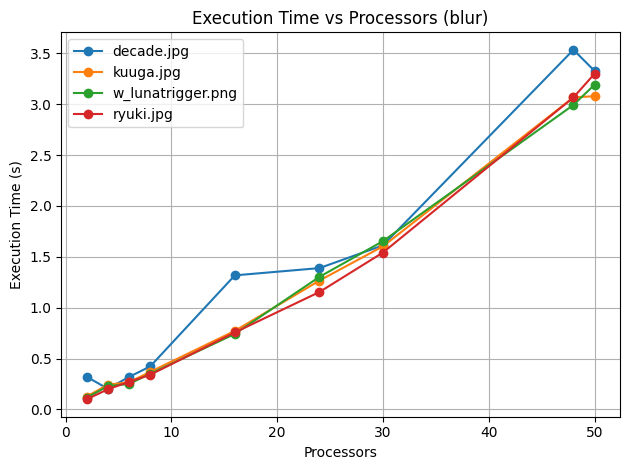

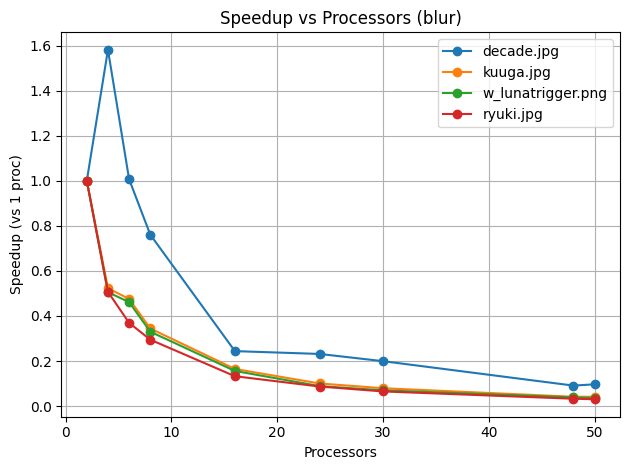

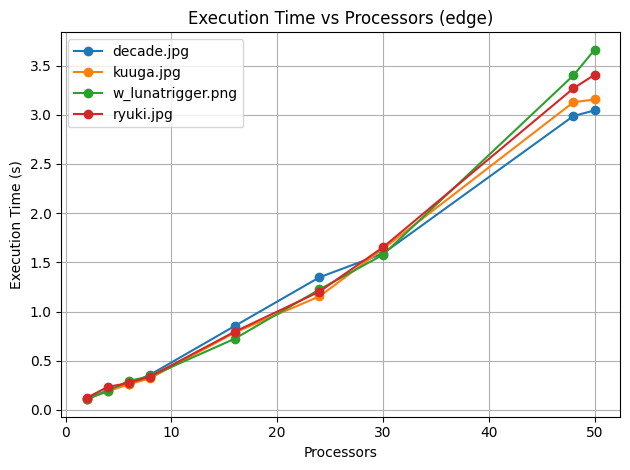

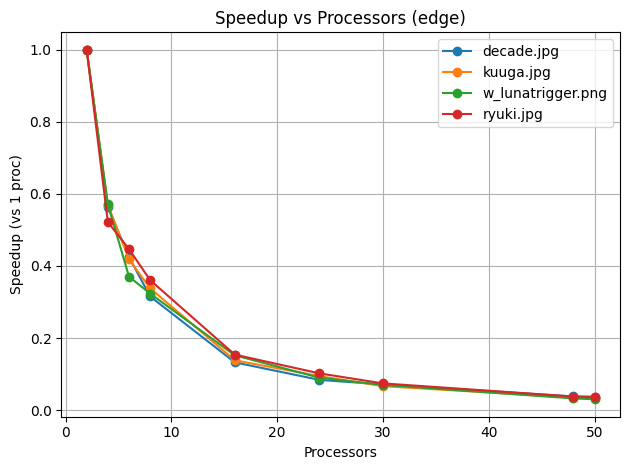

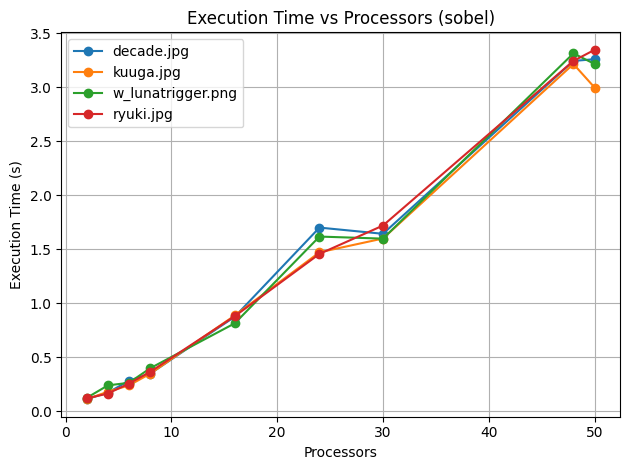

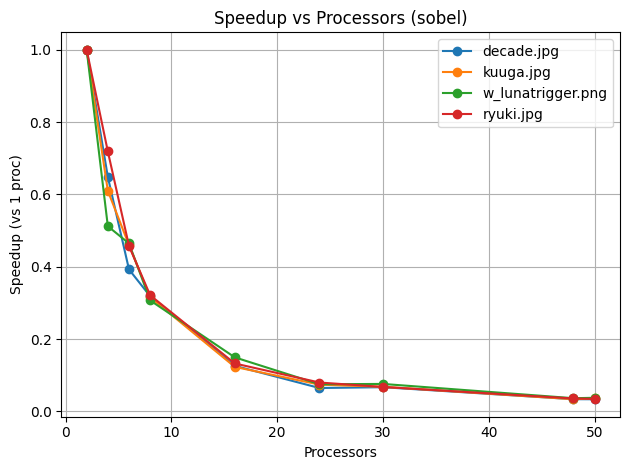

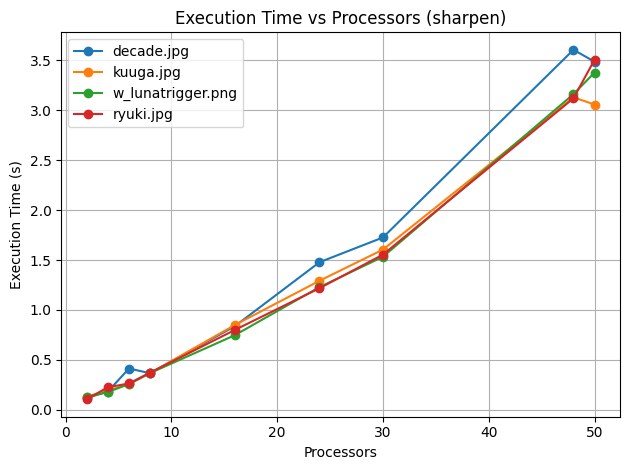

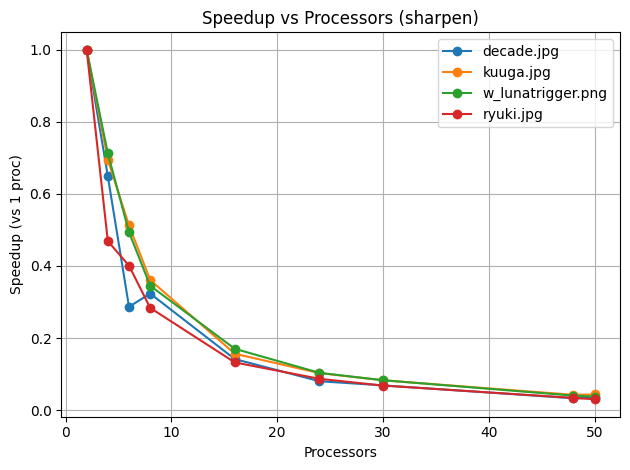

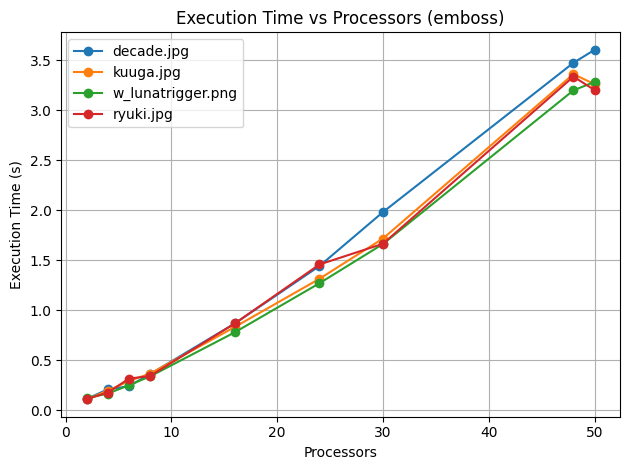

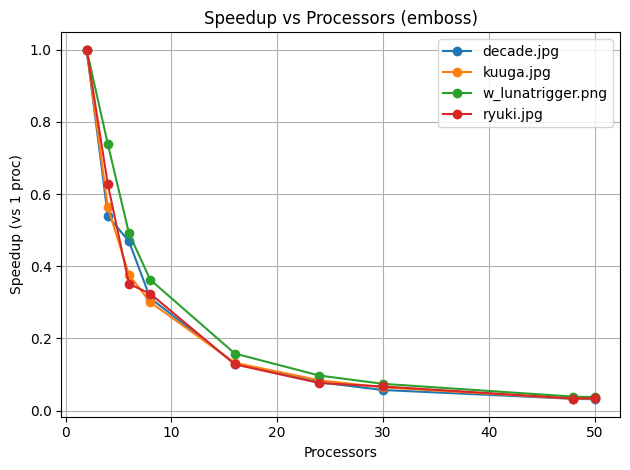

{'blur': [0.321627,
  0.203391,
  0.319454,
  0.422663,
  1.317845,
  1.389359,
  1.612753,
  3.53448,
  3.326626,
  0.127238,
  0.243198,
  0.267543,
  0.369393,
  0.772024,
  1.266688,
  1.603347,
  3.067288,
  3.078324,
  0.115801,
  0.229027,
  0.250974,
  0.35066,
  0.742437,
  1.303257,
  1.654211,
  2.992813,
  3.191888,
  0.100388,
  0.197929,
  0.271682,
  0.340484,
  0.756956,
  1.154509,
  1.542258,
  3.06624,
  3.299973],
 'edge': [0.113059,
  0.200384,
  0.266113,
  0.358531,
  0.853721,
  1.348248,
  1.589678,
  2.987609,
  3.04474,
  0.108729,
  0.190619,
  0.259941,
  0.321828,
  0.786645,
  1.154294,
  1.635588,
  3.127651,
  3.155443,
  0.110135,
  0.192966,
  0.297298,
  0.34056,
  0.724673,
  1.224446,
  1.576815,
  3.400885,
  3.660432,
  0.122503,
  0.234675,
  0.274259,
  0.339686,
  0.795816,
  1.202723,
  1.653062,
  3.268965,
  3.406542],
 'sobel': [0.110228,
  0.170006,
  0.280736,
  0.345871,
  0.873635,
  1.698593,
  1.641085,
  3.241883,
  3.257941,
  0.10

In [4]:
from pathlib import Path
import subprocess, re
import numpy as np
import matplotlib.pyplot as plt

# Uses your existing variables if already defined
procs = globals().get("procs", [2, 4, 6, 8, 16, 24, 30, 48, 50])
images = globals().get("images", ["decade.jpg", "kuuga.jpg", "w_lunatrigger.png", "ryuki.jpg"])
input_prefix = globals().get("input_prefix", r"./images/")
output_prefix = globals().get("output_prefix", r"./images/output")

MPIEXEC = globals().get("MPIEXEC", r"C:\Users\nyoma\scoop\apps\msmpi\10.1.1\mpiexec.exe")
PARALLEL_EXE = globals().get("PARALLEL_EXE", r"./scripts/parallel_image.exe")

ops = ["blur", "edge", "sobel", "sharpen", "emboss"]  # add "blur"/"edge" too if you want

time_re = re.compile(r"Time taken:\s*([0-9.]+)")

def run_op(op: str):
    times = []
    for image in images:
        stem = Path(image).stem  # safe for .jpg/.png/etc
        in_img = str(Path(input_prefix) / image)

        out_dir = Path(output_prefix) / op / stem
        out_dir.mkdir(parents=True, exist_ok=True)

        for p in procs:
            out_img = str(out_dir / f"{stem}_{p}.jpg")  # keep .jpg like your existing cells

            cmd = [
                MPIEXEC,
                "-n", str(p),
                PARALLEL_EXE,
                in_img,
                out_img,
                op,
            ]

            print("Running:", " ".join(cmd))
            result = subprocess.run(cmd, capture_output=True, text=True)

            combined = (result.stdout or "") + "\n" + (result.stderr or "")
            m = time_re.search(combined)
            if not m:
                raise RuntimeError(
                    f"Couldn't parse timing for op={op}, image={image}, p={p}\n--- output ---\n{combined}"
                )

            t = float(m.group(1))
            times.append(t)

    return times

# Run all requested ops
times_by_op = {}
for op in ops:
    times_by_op[op] = run_op(op)

# Plot time + speedup for each op (one figure each)
n_images = len(images)
n_procs = len(procs)

for op in ops:
    times_arr = np.array(times_by_op[op], dtype=float).reshape(n_images, n_procs)
    speedup_arr = times_arr[:, [0]] / times_arr

    plt.figure()
    for i, img in enumerate(images):
        plt.plot(procs, times_arr[i], marker="o", label=img)
    plt.xlabel("Processors")
    plt.ylabel("Execution Time (s)")
    plt.title(f"Execution Time vs Processors ({op})")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure()
    for i, img in enumerate(images):
        plt.plot(procs, speedup_arr[i], marker="o", label=img)
    plt.xlabel("Processors")
    plt.ylabel("Speedup (vs 1 proc)")
    plt.title(f"Speedup vs Processors ({op})")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

times_by_op

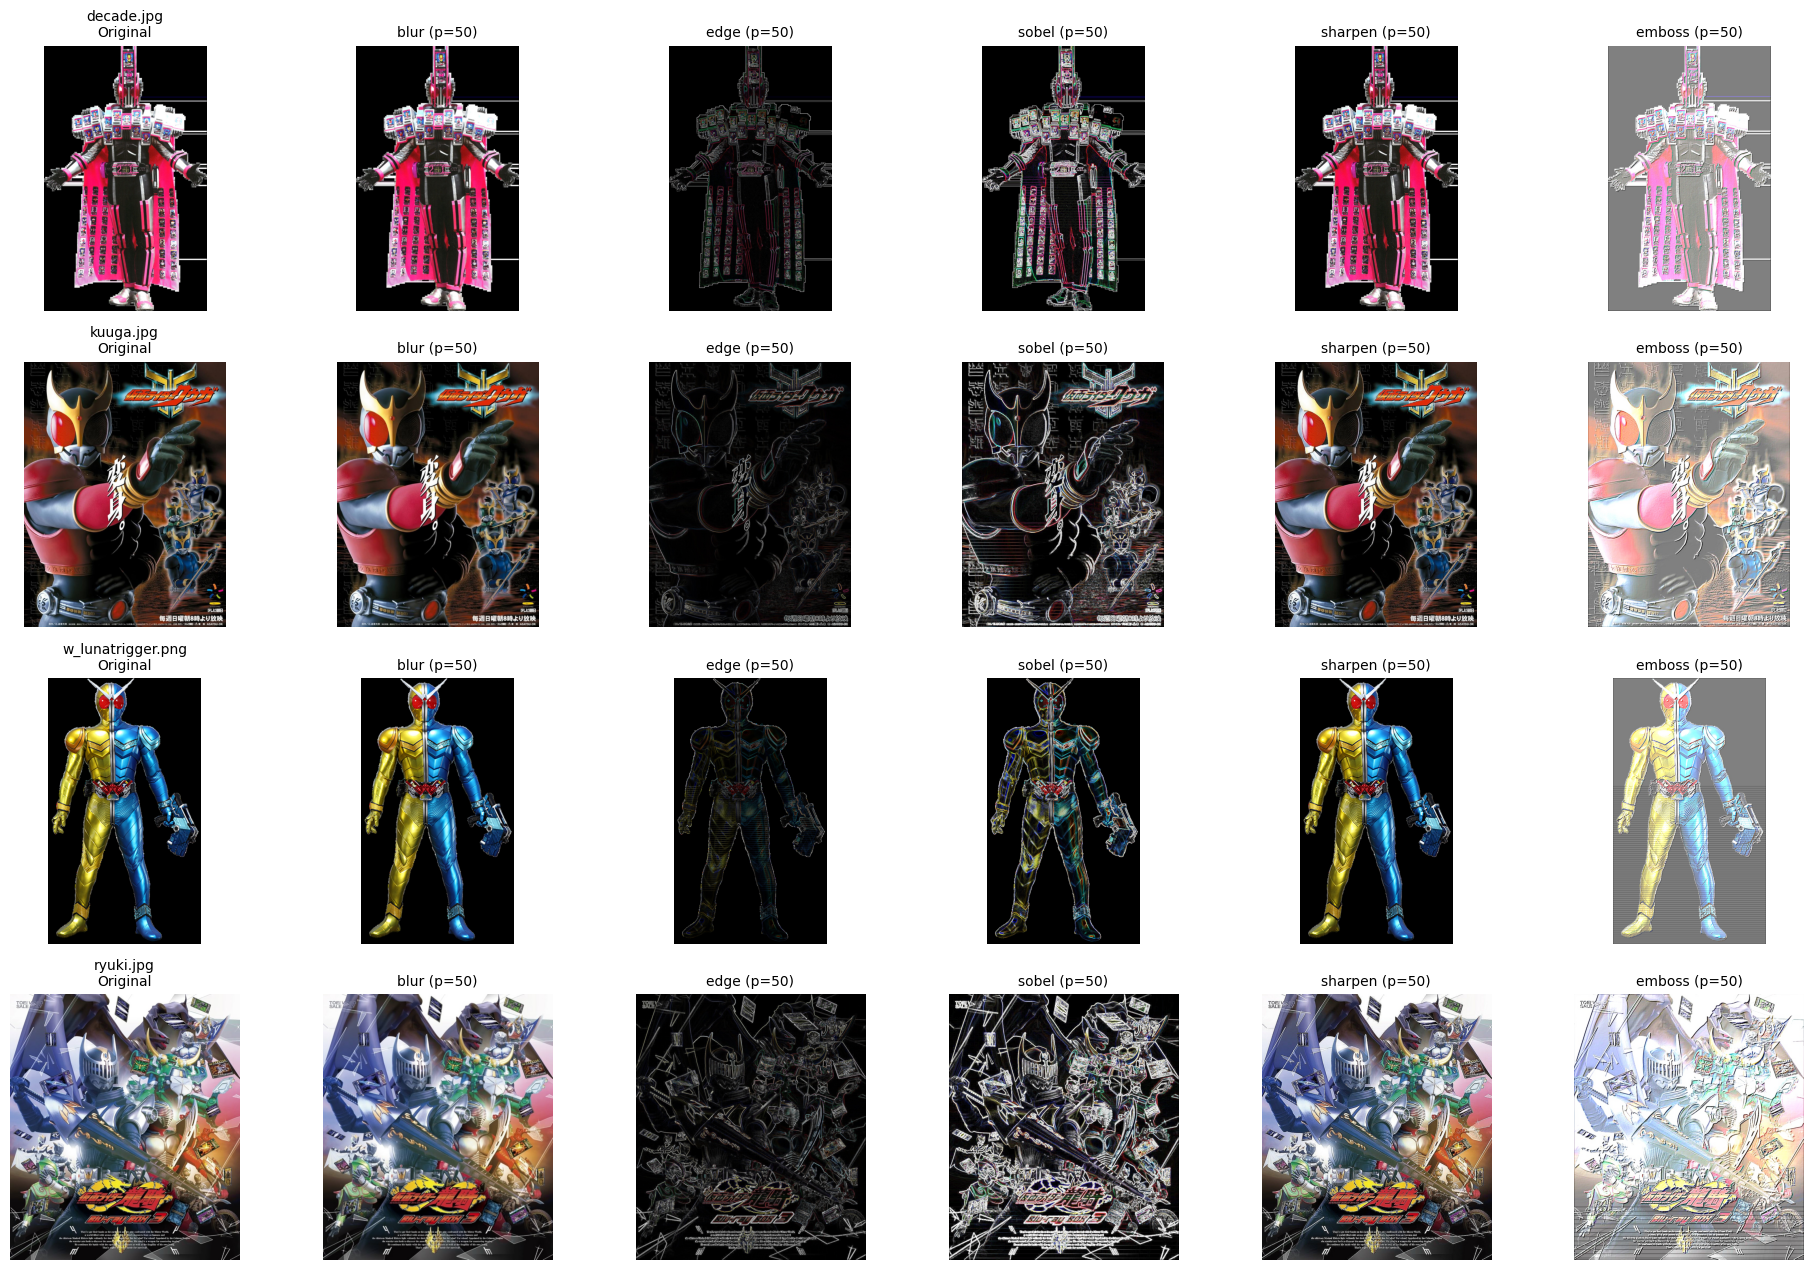

In [6]:
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt

# If you already defined these earlier, this will reuse them
images = globals().get("images", ["decade.jpg", "kuuga.jpg", "w_lunatrigger.png", "ryuki.jpg"])
input_prefix = globals().get("input_prefix", r"./images/")
output_prefix = globals().get("output_prefix", r"./images/output")
ops = globals().get("ops", ["blur", "edge", "sobel", "sharpen", "emboss"])

P = 50  # processor count to compare
cwd = Path(os.getcwd())

def _read_img(path: Path):
    # matplotlib handles jpg/png; force RGB for consistent display
    img = plt.imread(str(path))
    if isinstance(img, np.ndarray) and img.ndim == 3 and img.shape[2] == 4:
        img = img[:, :, :3]
    return img

n_rows = len(images)
n_cols = 1 + len(ops)  # original + each op

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(3.2 * n_cols, 3.2 * n_rows),
    squeeze=False
)

for r, image in enumerate(images):
    stem = Path(image).stem
    in_path = (cwd / input_prefix / image).resolve()

    # Original
    ax = axes[r, 0]
    if in_path.exists():
        ax.imshow(_read_img(in_path))
        ax.set_title(f"{image}\nOriginal", fontsize=10)
    else:
        ax.text(0.5, 0.5, f"Missing:\n{in_path}", ha="center", va="center")
        ax.set_title("Original (missing)", fontsize=10)
    ax.axis("off")

    # Processed
    for c, op in enumerate(ops, start=1):
        out_path = (cwd / output_prefix / op / stem / f"{stem}_{P}.jpg").resolve()
        ax = axes[r, c]
        if out_path.exists():
            ax.imshow(_read_img(out_path))
            ax.set_title(f"{op} (p={P})", fontsize=10)
        else:
            ax.text(0.5, 0.5, f"Missing:\n{out_path}", ha="center", va="center")
            ax.set_title(f"{op} (missing)", fontsize=10)
        ax.axis("off")

plt.tight_layout()
plt.show()